In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report
import pickle

In [2]:
df = pd.read_csv('./Data Files/Telco-Customer-Churn.csv')

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.value_counts('TotalCharges').sort_values()

TotalCharges
6875.35     1
103.7       1
1031.1      1
1031.4      1
1031.7      1
           ..
19.9        8
20.05       8
19.75       9
20.2       11
           11
Name: count, Length: 6531, dtype: int64

In [9]:
df.drop("customerID",axis=1,inplace=True)

In [10]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0.0")

In [11]:
categorical_features = {}
for cols in df.columns:
    if not pd.api.types.is_numeric_dtype(df[cols]):
        categorical_features[cols] = df[cols].unique()
        


In [12]:
categorical_features

{'gender': array(['Female', 'Male'], dtype=object),
 'Partner': array(['Yes', 'No'], dtype=object),
 'Dependents': array(['No', 'Yes'], dtype=object),
 'PhoneService': array(['No', 'Yes'], dtype=object),
 'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object),
 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
 'OnlineSecurity': array(['No', 'Yes', 'No internet service'], dtype=object),
 'OnlineBackup': array(['Yes', 'No', 'No internet service'], dtype=object),
 'DeviceProtection': array(['No', 'Yes', 'No internet service'], dtype=object),
 'TechSupport': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingTV': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingMovies': array(['No', 'Yes', 'No internet service'], dtype=object),
 'Contract': array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 'PaperlessBilling': array(['Yes', 'No'], dtype=object),
 'PaymentMethod': array(['Electronic check', 'Mailed 

In [13]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
#

In [15]:
df[df['TotalCharges']=="0.0"]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,0.0,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,0.0,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,0.0,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,0.0,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,0.0,No


In [16]:
df.TotalCharges = df.TotalCharges.astype(float)

In [17]:
# Checking the distribution of target columns
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Insights**
    
    Customer Id column was dropped as it was of no use in modeling
    
    No missing values in the dataset
    
    The missing values in TotalCharges were replaced with zero
    
    Class imbalance identified in the targ
    

### Exploratory data analysis

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Understand the distribution of numerical features

In [22]:
def plot_histogram(df,column_name):
   
    plt.figure(figsize=(8,4))
    sns.histplot(df[column_name], kde = True,bins= 50)
    plt.title(f"Distribution of {column_name}")

    col_mean = df[column_name].mean(numeric_only = True)
    col_median = df[column_name].median(numeric_only = True)

    plt.axvline(col_mean, color = 'red',linestyle = '--',label = 'Mean')
    plt.axvline(col_median, color = 'blue',linestyle = '-',label = 'Median')

    plt.legend()
    plt.show()



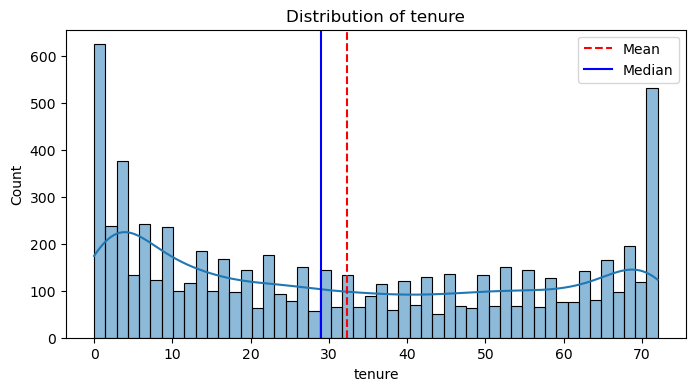

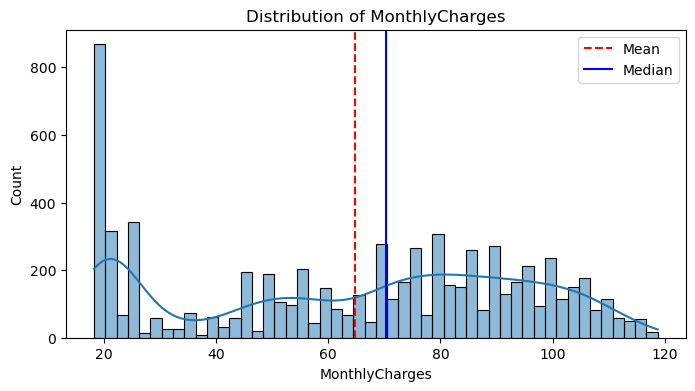

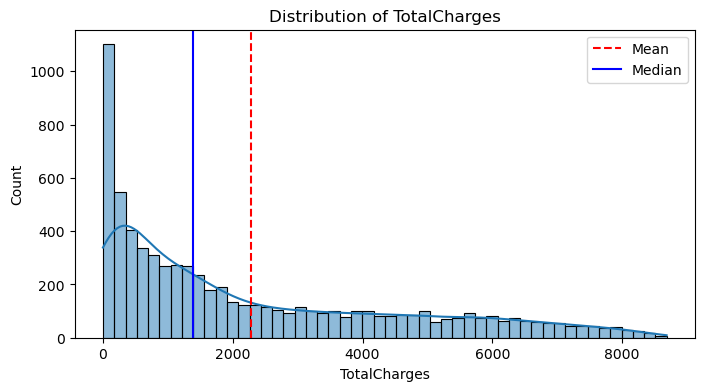

In [23]:
plot_histogram(df,"tenure")
plot_histogram(df,"MonthlyCharges")
plot_histogram(df,"TotalCharges")

In [24]:
def plot_boxplot(df,column_name):
   
    plt.figure(figsize=(5,3))
    sns.boxplot(df[column_name])
    plt.title(f"Box Plot of {column_name}")
    
    plt.show()


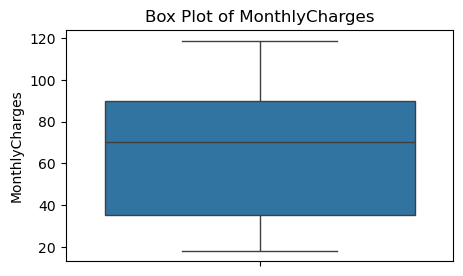

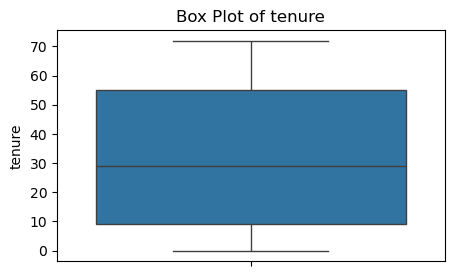

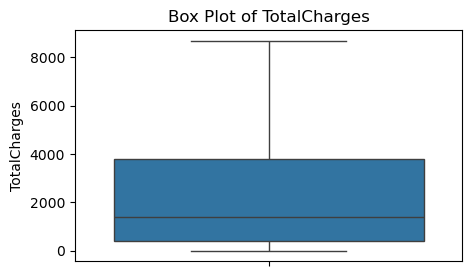

In [25]:
plot_boxplot(df,"MonthlyCharges") 
plot_boxplot(df,"tenure") 
plot_boxplot(df,"TotalCharges") 

### Correlation Matrix

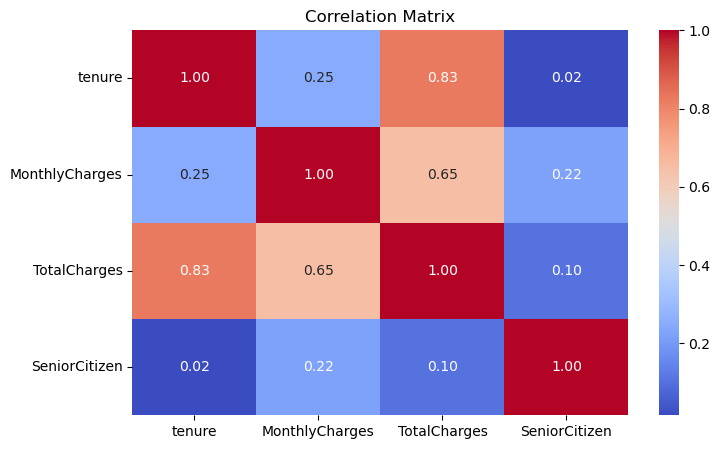

In [27]:
plt.figure(figsize=(8,5))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]].corr(),annot=True,cmap='coolwarm',fmt = '.2f')
plt.title("Correlation Matrix")
plt.show()

### Categorical Features

In [29]:
categorical_features["SeniorCitizen"] = df["SeniorCitizen"].value_counts()

In [30]:
categorical_features['SeniorCitizen'] = df['SeniorCitizen'].unique()

In [31]:
categorical_features

{'gender': array(['Female', 'Male'], dtype=object),
 'Partner': array(['Yes', 'No'], dtype=object),
 'Dependents': array(['No', 'Yes'], dtype=object),
 'PhoneService': array(['No', 'Yes'], dtype=object),
 'MultipleLines': array(['No phone service', 'No', 'Yes'], dtype=object),
 'InternetService': array(['DSL', 'Fiber optic', 'No'], dtype=object),
 'OnlineSecurity': array(['No', 'Yes', 'No internet service'], dtype=object),
 'OnlineBackup': array(['Yes', 'No', 'No internet service'], dtype=object),
 'DeviceProtection': array(['No', 'Yes', 'No internet service'], dtype=object),
 'TechSupport': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingTV': array(['No', 'Yes', 'No internet service'], dtype=object),
 'StreamingMovies': array(['No', 'Yes', 'No internet service'], dtype=object),
 'Contract': array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 'PaperlessBilling': array(['Yes', 'No'], dtype=object),
 'PaymentMethod': array(['Electronic check', 'Mailed 

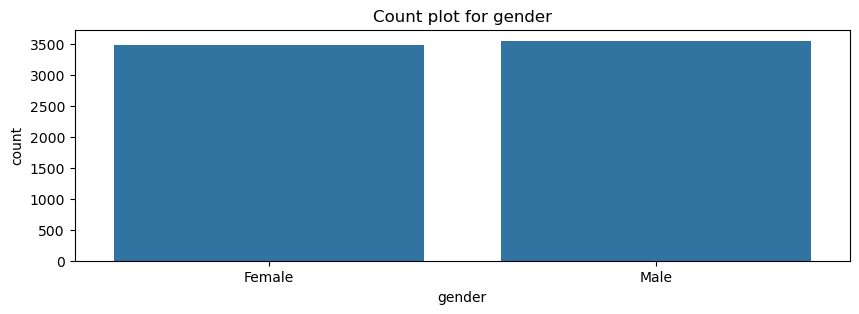

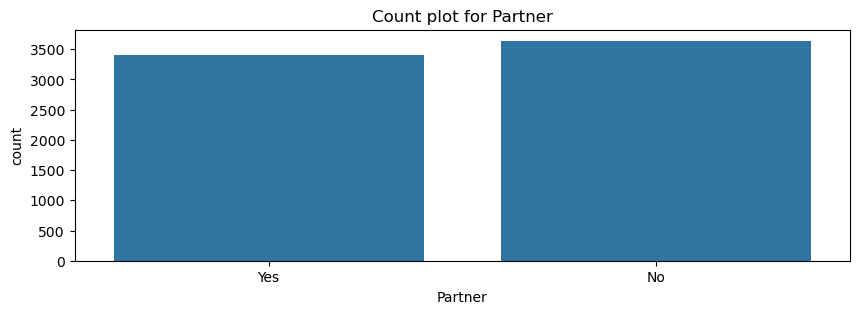

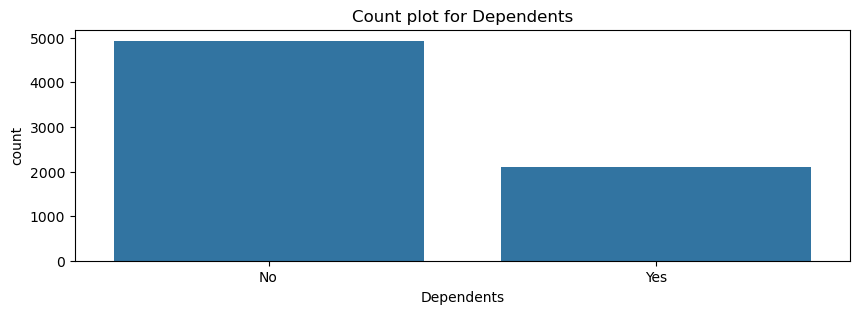

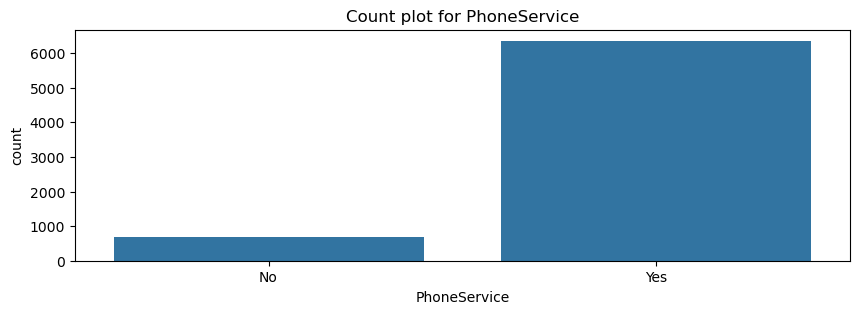

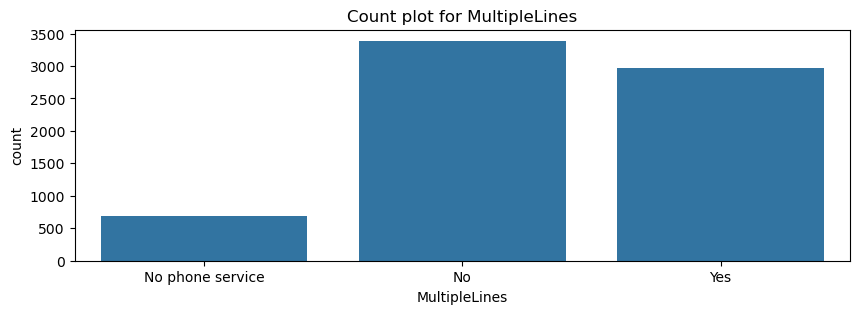

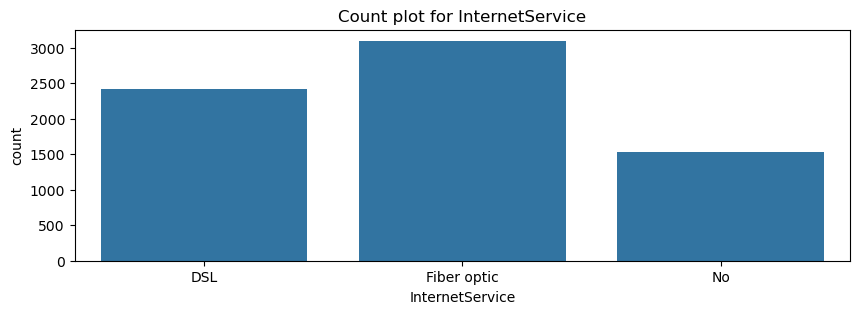

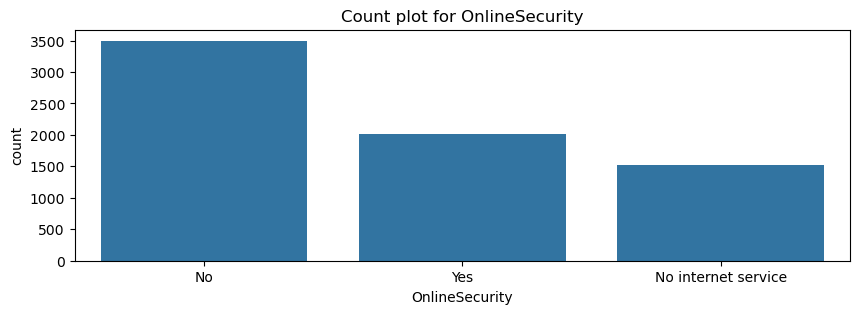

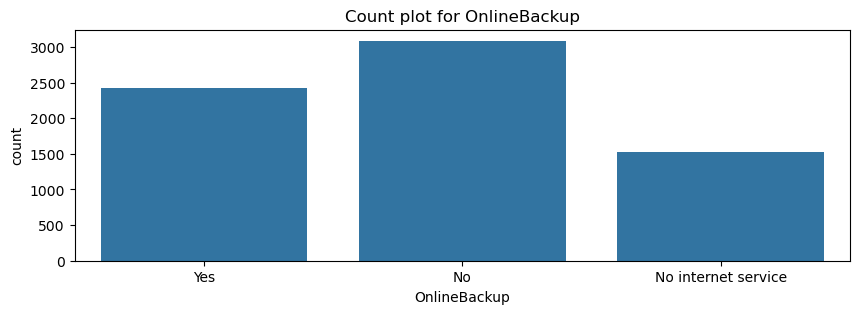

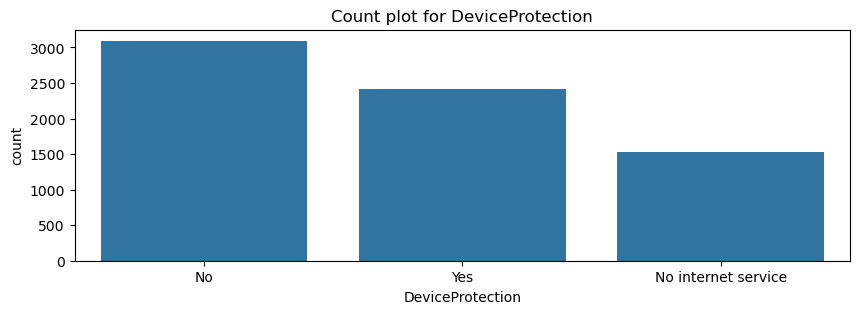

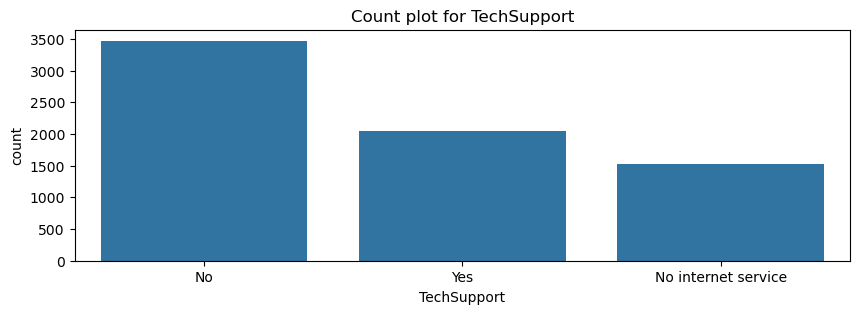

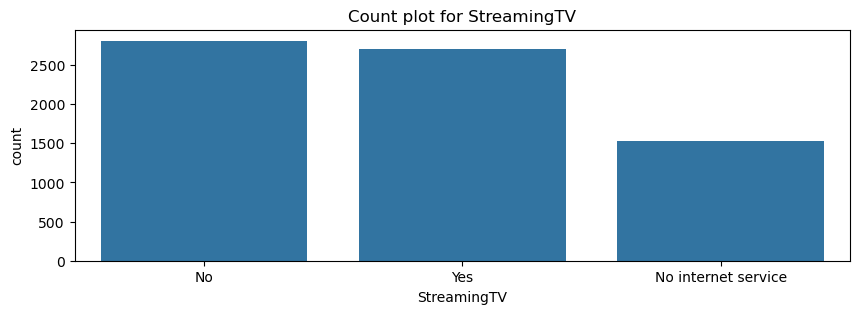

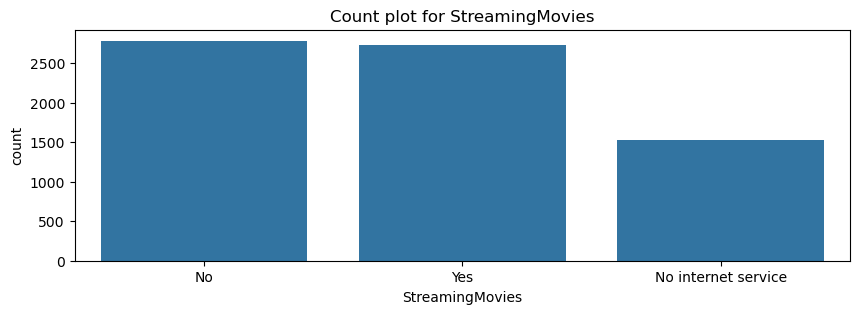

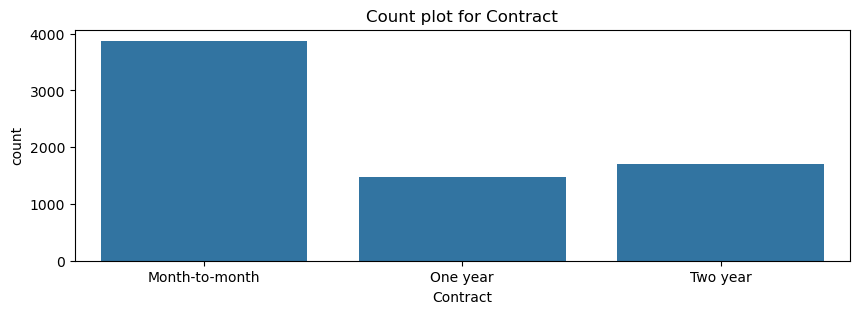

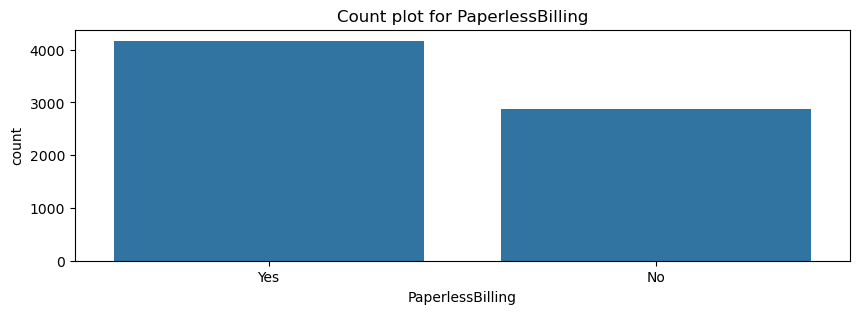

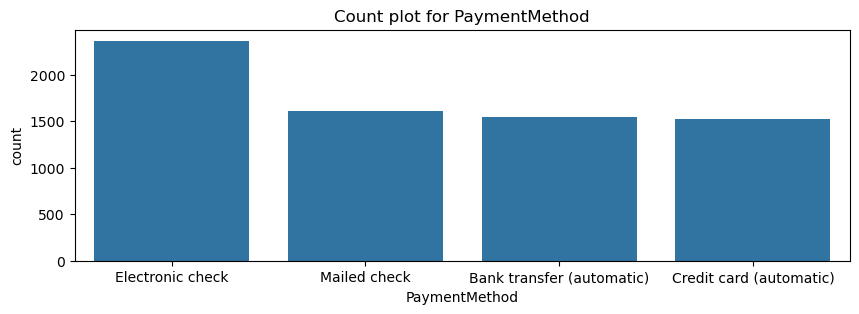

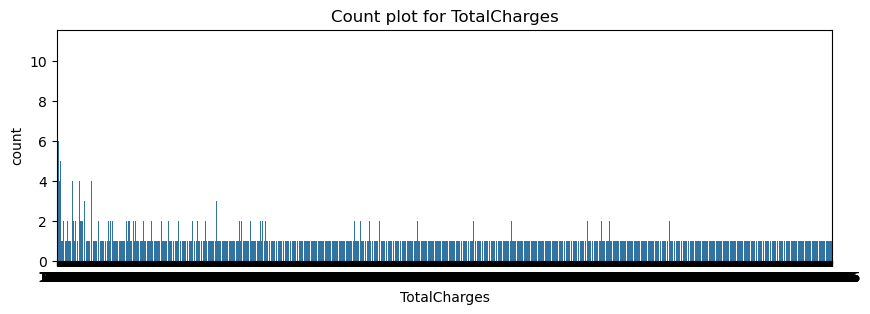

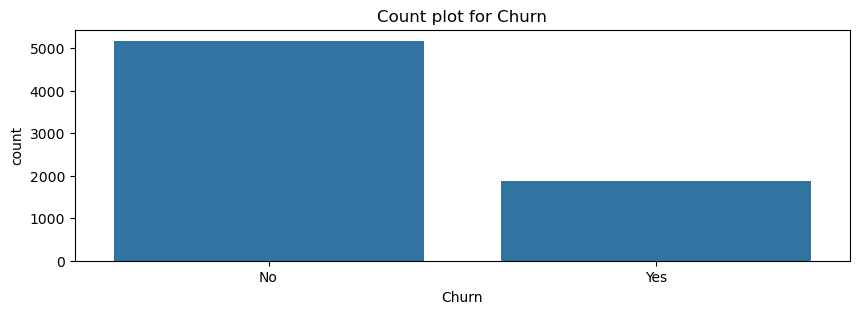

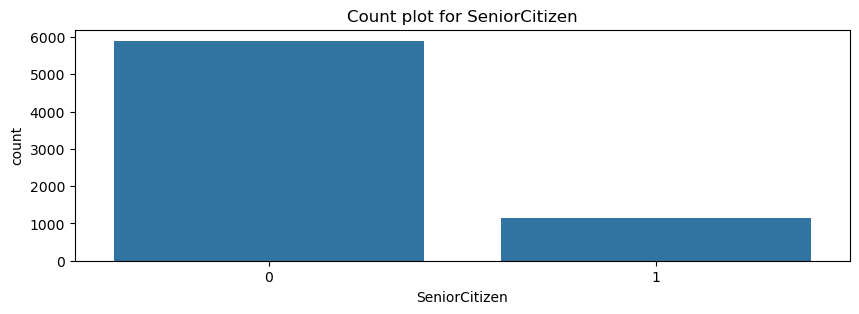

In [32]:
for col,values in categorical_features.items():
    plt.figure(figsize=(10,3))
    sns.countplot(x= df[col])
    plt.title(f"Count plot for {col}")
    plt.show()

### Data Preprocessing

In [34]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Label Encoding of target column

In [36]:
df.Churn = df.Churn.replace({"Yes":1,"No":0})

C:\Users\dmmd1\AppData\Local\Temp\ipykernel_1240\1617214323.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.Churn = df.Churn.replace({"Yes":1,"No":0})


In [37]:
df.Churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [39]:
df.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Label Encoding of categorical Features

In [41]:
object_columns =df.select_dtypes(include="object").columns

In [42]:
object_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [43]:
#Intitializing a dict to save encoders

encoders = {}

In [44]:
# apply lable encoding and store the encoders

for column in object_columns:
    label_encoder= LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder
    
with open('encoders.pkl','wb') as f:
    pickle.dump(encoders,f)

In [45]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Modeling 

In [47]:
X = df.drop("Churn",axis=1)
y = df.Churn

In [48]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2,random_state=42)

In [49]:
print(y_train.shape)

(5634,)


In [50]:
y_train.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [51]:
smote = SMOTE(random_state=42)

In [52]:
X_train_smote , y_train_smote = smote.fit_resample(X_train,y_train)

In [53]:
y_train_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [54]:
## Model Training

In [55]:
models = {
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest" :RandomForestClassifier(),
    "XGBoost" : XGBClassifier()
}

In [56]:
cv_scores ={}
for name , model in models.items():
     print(f"Training model {name} with default parameters")
     scores = cross_val_score( model, X_train_smote,y_train_smote,cv=5,scoring="accuracy")
     cv_scores[name] = scores
     print(f"{name} cross validation accuracy : {np.mean(scores):.2f}")

Training model Decision Tree with default parameters
Decision Tree cross validation accuracy : 0.78
Training model Random Forest with default parameters
Random Forest cross validation accuracy : 0.84
Training model XGBoost with default parameters
XGBoost cross validation accuracy : 0.83


In [57]:
cv_scores

{'Decision Tree': array([0.68115942, 0.71540785, 0.82537764, 0.84169184, 0.84652568]),
 'Random Forest': array([0.727657  , 0.76918429, 0.90271903, 0.89969789, 0.89848943]),
 'XGBoost': array([0.70833333, 0.76132931, 0.90453172, 0.88821752, 0.90755287])}

## Random Forest gives the highest accuracy compared to the other models with default parameters

In [59]:
rfc = RandomForestClassifier()

In [60]:
model.fit(X_train_smote,y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### Model evaluation

In [62]:
y_test_preds = model.predict(X_test)

print("Accuracy score :", accuracy_score(y_test,y_test_preds))
print("Confusion matrix :", confusion_matrix(y_test,y_test_preds))
print("Classification Report :", classification_report(y_test,y_test_preds))

Accuracy score : 0.7856635911994322
Confusion matrix : [[883 153]
 [149 224]]
Classification Report :               precision    recall  f1-score   support

           0       0.86      0.85      0.85      1036
           1       0.59      0.60      0.60       373

    accuracy                           0.79      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [63]:
rfc.fit(X_train_smote,y_train_smote)

RandomForestClassifier()

In [64]:
y_test_pred = rfc.predict(X_test)
print("Accuracy score :", accuracy_score(y_test,y_test_preds))
print("Confusion matrix :", confusion_matrix(y_test,y_test_preds))
print("Classification Report :", classification_report(y_test,y_test_preds))

Accuracy score : 0.7856635911994322
Confusion matrix : [[883 153]
 [149 224]]
Classification Report :               precision    recall  f1-score   support

           0       0.86      0.85      0.85      1036
           1       0.59      0.60      0.60       373

    accuracy                           0.79      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [132]:
model_data = {"model":rfc, "features":X.columns.tolist()}

with open("customer_churn_model.pkl","wb") as f:
    pickle.dump(model_data,f)

## Load the saved Model and build a predictive system

In [134]:
with open("customer_churn_model.pkl","rb") as f:
    model_data = pickle.load(f)

In [144]:
loaded_model = model_data['model']
feature_names = model_data['features']

In [168]:
input_data = ["Female",0,"Yes","Yes",11,"Yes","No","No","No internet service","No internet service","No internet service","No internet service","No internet service","No internet service","One year","No"	,"Mailed check",20.6,	233.9]

In [174]:
input_data_df = pd.DataFrame(data=[input_data],columns=['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'])

In [184]:
with open("encoders.pkl","rb") as f:
    encoders = pickle.load(f)

In [186]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [190]:
for column, encoder in encoders.items():
    input_data_df[column] = encoder.transform(input_data_df[column])

In [196]:
predictions = loaded_model.predict(input_data_df)

In [206]:
print(f"Prediction: {"Churn" if predictions[0] == 1 else "No Churn"}")

Prediction: No Churn
